In [1]:
!pip install umap-learn


   -------------------- ------------------- 1/2 [umap-learn]
   ---------------------------------------- 2/2 [umap-learn]



### UMAP 

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    classification_report,
    confusion_matrix
)
from sklearn.cluster import KMeans
import umap
import time

In [5]:

# UMAP 2D 
t0 = time.time()
reducer_2d = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=42,
    verbose=False
)
X_umap_2d = reducer_2d.fit_transform(X_norm)
t_umap = time.time() - t0
print(f"    UMAP 2D terminé en {t_umap:.1f}s | Shape : {X_umap_2d.shape}")


# ÉVALUATION

# Silhouette Score : qualité de séparation des clusters
sil_raw  = silhouette_score(X_norm,    y, sample_size=2000, random_state=42)
sil_umap = silhouette_score(X_umap_2d, y, random_state=42)
print(f"\n    Silhouette Score:")
print(f"      Espace original (784D) : {sil_raw:.4f}")
print(f"      Espace UMAP-2D         : {sil_umap:.4f}  (+{(sil_umap - sil_raw) / sil_raw * 100:.1f}%)")

# KNN-5 sur projection UMAP vs espace original (pour voir si la réduction de dimensionnalité a conservé l'information essentielle)
X_tr,   X_te,   y_tr,   y_te   = train_test_split(X_umap_2d, y, test_size=0.2, random_state=42, stratify=y)
X_tr_r, X_te_r, y_tr_r, y_te_r = train_test_split(X_norm,    y, test_size=0.2, random_state=42, stratify=y)

knn_umap = KNeighborsClassifier(n_neighbors=5)
knn_umap.fit(X_tr, y_tr)
acc_umap = knn_umap.score(X_te, y_te)

knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_tr_r, y_tr_r)
acc_raw = knn_raw.score(X_te_r, y_te_r)

print(f"\n    Accuracy KNN-5 (20% test) :")
print(f"      Espace original (784D) : {acc_raw:.4f}  ({acc_raw * 100:.1f}%)")
print(f"      Espace UMAP-2D         : {acc_umap:.4f}  ({acc_umap * 100:.1f}%)")

# Adjusted Rand Score : KMeans sur UMAP vs labels réels
km = KMeans(n_clusters=10, random_state=42, n_init=10)
labels_km = km.fit_predict(X_umap_2d)
ari = adjusted_rand_score(y, labels_km)
print(f"\n    Adjusted Rand Score (KMeans-10 vs labels) : {ari:.4f}")

# F1-score par chiffre
y_pred = knn_umap.predict(X_te)
report = classification_report(y_te, y_pred, output_dict=True)
print(f"\n    F1-score par classe :")
for digit in range(10):
    f1  = report[str(digit)]["f1-score"]
    bar = "█" * int(f1 * 20)
    print(f"      Chiffre {digit} : {bar:<20} {f1:.3f}")



    UMAP 2D terminé en 16.5s | Shape : (10000, 2)

    Silhouette Score:
      Espace original (784D) : 0.0390
      Espace UMAP-2D         : 0.4177  (+972.3%)

    Accuracy KNN-5 (20% test) :
      Espace original (784D) : 0.9450  (94.5%)
      Espace UMAP-2D         : 0.9420  (94.2%)

    Adjusted Rand Score (KMeans-10 vs labels) : 0.7279

    F1-score par classe :
      Chiffre 0 : ███████████████████  0.963
      Chiffre 1 : ███████████████████  0.952
      Chiffre 2 : ██████████████████   0.930
      Chiffre 3 : ██████████████████   0.938
      Chiffre 4 : ███████████████████  0.952
      Chiffre 5 : ██████████████████   0.938
      Chiffre 6 : ███████████████████  0.968
      Chiffre 7 : ██████████████████   0.948
      Chiffre 8 : ██████████████████   0.922
      Chiffre 9 : ██████████████████   0.907


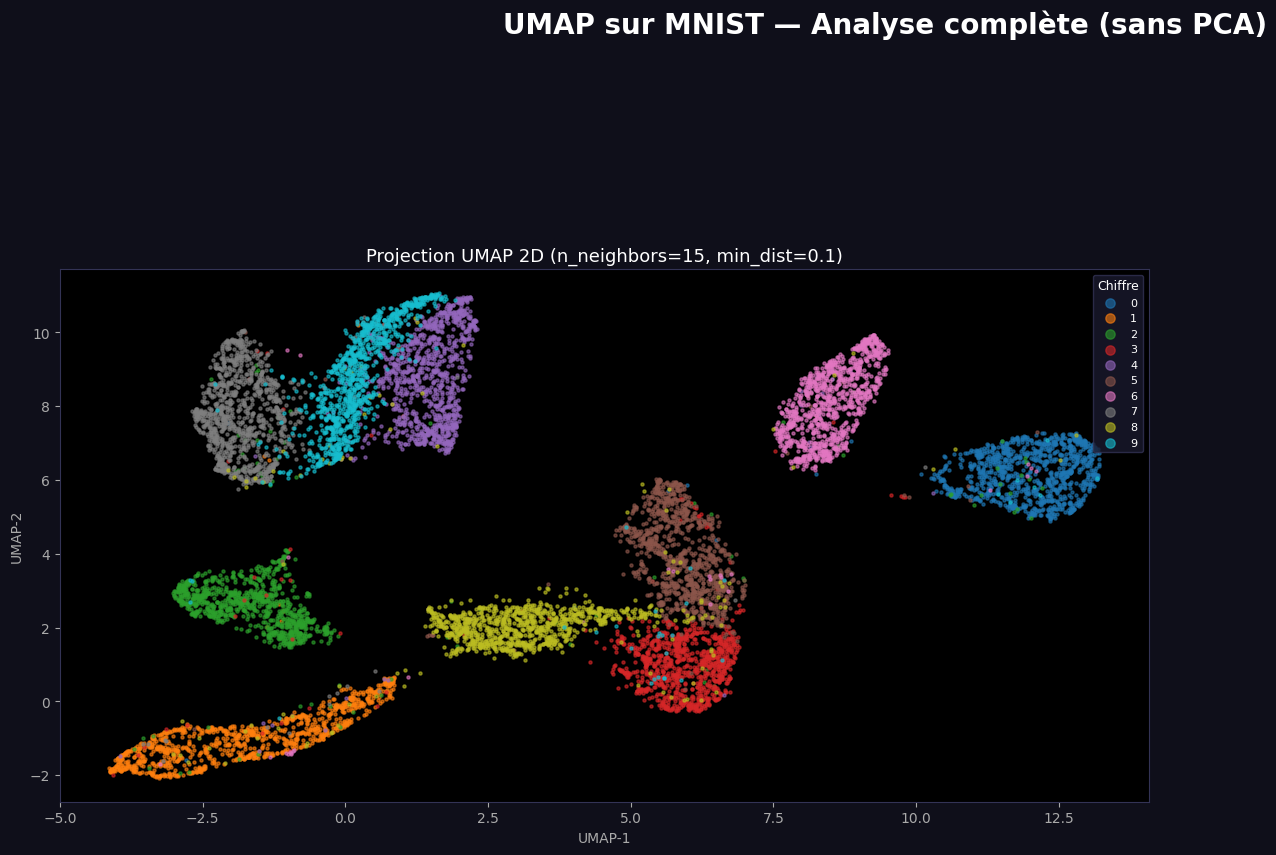

In [6]:
# VISUALISATION

COLORS = plt.cm.tab10(np.linspace(0, 1, 10))
plt.style.use("dark_background")

fig = plt.figure(figsize=(22, 26), facecolor="#0f0f1a")
fig.suptitle("UMAP sur MNIST — Analyse complète (sans PCA)",
             fontsize=20, fontweight="bold", color="white", y=0.98)

gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.38, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :2])
for digit in range(10):
    mask = y == digit
    ax1.scatter(X_umap_2d[mask, 0], X_umap_2d[mask, 1],
                c=[COLORS[digit]], s=5, alpha=0.6, label=str(digit))
ax1.set_title("Projection UMAP 2D (n_neighbors=15, min_dist=0.1)", fontsize=13, color="white")
ax1.set_xlabel("UMAP-1", color="#aaaaaa")
ax1.set_ylabel("UMAP-2", color="#aaaaaa")
ax1.tick_params(colors="#aaaaaa")
for spine in ax1.spines.values():
    spine.set_color("#333355")
leg = ax1.legend(title="Chiffre", loc="upper right", fontsize=8,
                 title_fontsize=9, markerscale=3,
                 labelcolor="white", facecolor="#1a1a2e", edgecolor="#333355")
leg.get_title().set_color("white")